<a href="https://colab.research.google.com/github/sabrina-hilario/fundamentos/blob/main/Playlist_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Como selecionar valor único : Aula 1 **


In [ ]:
import pandas as pd
dados = {'col1': [10,20,30], 'col2': [40,50,60],'col3': [70,80,90]}
df = pd.DataFrame(dados, index=['lin1','lin2','lin3'])

In [ ]:
df

,col1,col2,col3
lin1,10,40,70
lin2,20,50,80
lin3,30,60,90


In [ ]:
Valor = df['col2']['lin2']
print(Valor)

50


In [ ]:
df.at['lin3','col2']
print(Valor)


50


Para a substituir um valor no DataFrame, basta colocar o sinal de igual na frente do colchete, com  número desejado.

In [ ]:
df.at['lin2','col2']=6
df

,col1,col2,col3
lin1,10,40,70
lin2,20,6,80
lin3,30,60,90


**AULA 2 : Como Filtrar Dados com LOC e ILOC **

In [ ]:
import pandas as pd

dados = {'col1': [2,5,2,7], 'col2':[4,4,9,1]}
df = pd.DataFrame(dados, index=['lin1', 'lin2', 'lin3', 'lin4'])


In [ ]:
df

,col1,col2
lin1,2,4
lin2,5,4
lin3,2,9
lin4,7,1


In [ ]:
df.loc ['lin1']


,lin1
col1,2
col2,4


In [ ]:
df.loc[['lin1']]


,col1,col2
lin1,2,4


In [ ]:
df.loc [['lin1', 'lin2']]

,col1,col2
lin1,2,4
lin2,5,4


IndexError: index 2 is out of bounds for axis 0 with size 2

**AULA 14:**  como agrupar dados

In [ ]:
import pandas as pd
dados_eleição = {'SG_UF':['SP','SP','RJ','RJ','AC','AC','SP','RJ','AC','SP'],'SG_PARTIDO':['XYZ','ABC','XYZ','ABC','XYZ','XYZ','ABC','XYZ','ABC','XYZ'],'DS_CARGO':['VEREADOR','VEREADOR','PREFEITO','PREFEITO','VEREADOR','PREFEITO','PREFEITO','VEREADOR','PREFEITO','VEREADOR'], 'NR_TURNO':[1,1,1,1,1,1,1,1,1,1],'QT_VOTOS_NOMINAIS':[1500,2300,4500,1200,800,3100,5000,950,400,1800],'QT_VOTOS_LEGENDA':[10,15,20,5,12,30,8,3,11,20]}
df = pd.DataFrame(dados_eleição)
print("===BASE DE DADOS ORIGINAL(df)===")
print(df)
print("\n"+"="*80+"\n")

===BASE DE DADOS ORIGINAL(df)===
  SG_UF SG_PARTIDO  DS_CARGO  NR_TURNO  QT_VOTOS_NOMINAIS  QT_VOTOS_LEGENDA
0    SP        XYZ  VEREADOR         1               1500                10
1    SP        ABC  VEREADOR         1               2300                15
2    RJ        XYZ  PREFEITO         1               4500                20
3    RJ        ABC  PREFEITO         1               1200                 5
4    AC        XYZ  VEREADOR         1                800                12
5    AC        XYZ  PREFEITO         1               3100                30
6    SP        ABC  PREFEITO         1               5000                 8
7    RJ        XYZ  VEREADOR         1                950                 3
8    AC        ABC  PREFEITO         1                400                11
9    SP        XYZ  VEREADOR         1               1800                20




In [ ]:
print("CÓDIGO 1: df.groupby('SG_UF').sum()")
df.groupby('SG_UF').sum()


CÓDIGO 1: df.groupby('SG_UF').sum()


,SG_PARTIDO,DS_CARGO,NR_TURNO,QT_VOTOS_NOMINAIS,QT_VOTOS_LEGENDA
SG_UF,,,,,
AC,XYZXYZABC,VEREADORPREFEITOPREFEITO,3,4300,53
RJ,XYZABCXYZ,PREFEITOPREFEITOVEREADOR,3,6650,28
SP,XYZABCABCXYZ,VEREADORVEREADORPREFEITOVEREADOR,4,10600,53


In [ ]:
df.groupby(['SG_UF','SG_PARTIDO']).sum()

DS_CARGO  NR_TURNO  QT_VOTOS_NOMINAIS  \
SG_UF SG_PARTIDO                                                  
AC    ABC                 PREFEITO         1                400   
      XYZ         VEREADORPREFEITO         2               3900   
RJ    ABC                 PREFEITO         1               1200   
      XYZ         PREFEITOVEREADOR         2               5450   
SP    ABC         VEREADORPREFEITO         2               7300   
      XYZ         VEREADORVEREADOR         2               3300   

                  QT_VOTOS_LEGENDA  
SG_UF SG_PARTIDO                    
AC    ABC                       11  
      XYZ                       42  
RJ    ABC                        5  
      XYZ                       23  
SP    ABC                       23  
      XYZ                       30

In [ ]:
df.groupby('SG_UF').agg({'QT_VOTOS_NOMINAIS':'sum'})
df.groupby('SG_UF').agg({'QT_VOTOS_NOMINAIS':'sum'})

,QT_VOTOS_NOMINAIS
SG_UF,
AC,4300
RJ,6650
SP,10600


In [ ]:
df.groupby(['SG_UF','SG_PARTIDO','DS_CARGO','NR_TURNO']).sum().head(50)

QT_VOTOS_NOMINAIS  QT_VOTOS_LEGENDA
SG_UF SG_PARTIDO DS_CARGO NR_TURNO                                     
AC    ABC        PREFEITO 1                       400                11
      XYZ        PREFEITO 1                      3100                30
                 VEREADOR 1                       800                12
RJ    ABC        PREFEITO 1                      1200                 5
      XYZ        PREFEITO 1                      4500                20
                 VEREADOR 1                       950                 3
SP    ABC        PREFEITO 1                      5000                 8
                 VEREADOR 1                      2300                15
      XYZ        VEREADOR 1                      3300                30

In [ ]:
df.groupby(['SG_UF','SG_PARTIDO','DS_CARGO','NR_TURNO'], as_index=False).sum().head(50)

,SG_UF,SG_PARTIDO,DS_CARGO,NR_TURNO,QT_VOTOS_NOMINAIS,QT_VOTOS_LEGENDA
0,AC,ABC,PREFEITO,1,400,11
1,AC,XYZ,PREFEITO,1,3100,30
2,AC,XYZ,VEREADOR,1,800,12
3,RJ,ABC,PREFEITO,1,1200,5
4,RJ,XYZ,PREFEITO,1,4500,20
5,RJ,XYZ,VEREADOR,1,950,3
6,SP,ABC,PREFEITO,1,5000,8
7,SP,ABC,VEREADOR,1,2300,15
8,SP,XYZ,VEREADOR,1,3300,30


In [ ]:
df.groupby('SG_UF').agg({'QT_VOTOS_NOMINAIS':'sum','QT_VOTOS_LEGENDA':'mean'})

,QT_VOTOS_NOMINAIS,QT_VOTOS_LEGENDA
SG_UF,,
AC,4300,17.666667
RJ,6650,9.333333
SP,10600,13.250000


In [ ]:
df.groupby('SG_UF').size()

,0
SG_UF,
AC,3
RJ,3
SP,4


In [ ]:
df.groupby('SG_UF').agg({'QT_VOTOS_LEGENDA':'mean'})

,QT_VOTOS_LEGENDA
SG_UF,
AC,17.666667
RJ,9.333333
SP,13.250000


**Explicação**

**.sum()**: É uma das variações possíveis de agrupamento, sendo responsável por somar apenas todas as colunas numéricas

**.mean()**:  É outra possibilidade de agrupamento, ele calcula a média das colunas numéricas

**.agg()**: É uma função que permite calcular mais de uma variação ao mesmo tempo ou aplicar diferentes cálculos para cada coluna


**AULA 15:**   Como pivotar dados




In [70]:
import pandas as pd

dados = {
    'SG_PARTIDO': ['PT', 'PL', 'PT', 'PL'],
    'DS_CARGO': ['PREFEITO', 'PREFEITO', 'VEREADOR', 'VEREADOR'],
    'VOTOS': [1500, 2000, 500, 800]
}

df = pd.DataFrame(dados)


In [71]:
df.pivot_table(index='SG_PARTIDO', columns='DS_CARGO', values='VOTOS')

DS_CARGO,PREFEITO,VEREADOR
SG_PARTIDO,,
PL,2000.0,800.0
PT,1500.0,500.0


**pivot_table():** é o método de criar tabelas,agrupando e organizando grandes volumes de dados,ele consegue lidar com dados duplicados

**pivot():** Esse método é utilizado exclusivamente para redesenhar a estrutura de uma tabela, não sendo capaz de realizar nenhuma operação matemática



In [72]:
import pandas as pd

dados = {
    'SG_PARTIDO': ['PT', 'PT', 'PL', 'PL'],
    'DS_CARGO': ['PREFEITO', 'PREFEITO', 'PREFEITO', 'VEREADOR'],
    'ZONA': ['Zona 1', 'Zona 2', 'Zona 1', 'Zona 1'],
    'VOTOS': [100, 150, 200, 300]
}
df = pd.DataFrame(dados)


In [74]:
df.pivot_table(index='SG_PARTIDO', columns='DS_CARGO', values='VOTOS', aggfunc='sum')


DS_CARGO,PREFEITO,VEREADOR
SG_PARTIDO,,
PL,200.0,300.0
PT,250.0,NaN


In [75]:

resultado = df.pivot_table(index='SG_PARTIDO', columns='DS_CARGO', values='VOTOS', aggfunc='sum')
print(resultado)


DS_CARGO    PREFEITO  VEREADOR
SG_PARTIDO                    
PL             200.0     300.0
PT             250.0       NaN


In [77]:
import pandas as pd
import numpy as np

dados = {
    'SG_PARTIDO': ['PT', 'PT', 'PL', 'PL', 'PT', 'PL'],
    'DS_CARGO': ['PREFEITO', 'PREFEITO', 'PREFEITO', 'VEREADOR', 'VEREADOR', 'VEREADOR'],
    'VOTOS': [100, 150, 200, 300, 80, 120]
}
df = pd.DataFrame(dados)


In [78]:

tabela_soma = df.pivot_table(
    index='SG_PARTIDO',
    columns='DS_CARGO',
    values='VOTOS',
    aggfunc='sum',
    fill_value=0
)
print(tabela_soma)



DS_CARGO    PREFEITO  VEREADOR
SG_PARTIDO                    
PL               200       420
PT               250        80


**AULA 40:**  Qual função escolher para aplicar funções?



In [5]:
import pandas as pd
dados_candidatos = { 'CANDIDATO':['Ana Silva','Bruno Costa','Crlos Souza','Daniela Lima'],'SG_PARTIDO':['XYZ','ABC','XYZ','ABC'], 'VOTOS_TURNO_1':[1500,2300,4500,800],'VOTOS_TURNO_2':[1200,3100,5000,950]}

df=pd.DataFrame(dados_candidatos)

print("===BASE DE DADOS ORIGINAL(df)===")
print(df)
print("\n"+"="*80+"\n")


===BASE DE DADOS ORIGINAL(df)===
      CANDIDATO SG_PARTIDO  VOTOS_TURNO_1  VOTOS_TURNO_2
0     Ana Silva        XYZ           1500           1200
1   Bruno Costa        ABC           2300           3100
2   Crlos Souza        XYZ           4500           5000
3  Daniela Lima        ABC            800            950




In [9]:
df['VOTOS_TURNO_2'].apply(lambda x: x**2)


,VOTOS_TURNO_2
0,1440000
1,9610000
2,25000000
3,902500


In [13]:
def soma(*args):
  return sum(args)

In [15]:
df['VOTOS_TURNO_2'].apply(soma, args=(1,2,3))

,VOTOS_TURNO_2
0,1206
1,3106
2,5006
3,956


In [19]:
df = pd.DataFrame ([[1,2,[1,2,3,]],[3,4,[4,5,6,]],[5,6,[7,8,9,]]], columns=['col1','col2','col3',])


In [20]:
df

,col1,col2,col3
0,1,2,"[1, 2, 3]"
1,3,4,"[4, 5, 6]"
2,5,6,"[7, 8, 9]"


In [21]:
df['col3'].apply(lambda item: [x**2 if x == 2 else x for x in item])

,col3
0,"[1, 4, 3]"
1,"[4, 5, 6]"
2,"[7, 8, 9]"


In [22]:
df = df.drop('col3',axis=1)

In [23]:
df

,col1,col2
0,1,2
1,3,4
2,5,6


In [26]:
df.apply(lambda x: 'col1' if x.col1 > x.col2 else 'col2', axis=1)

,0
0,col2
1,col2
2,col2


KeyError: "None of [Index(['CANDIDATO', 'VOTOS_TURNO_1', 'VOTOS_TURNO_2'], dtype='object')] are in the [columns]"

In [33]:
import pandas as pd
dados_candidatos = { 'CANDIDATO':['Ana Silva','Bruno Costa','Crlos Souza','Daniela Lima'],'SG_PARTIDO':['XYZ','ABC','XYZ','ABC'], 'VOTOS_TURNO_1':[1500,2300,4500,800],'VOTOS_TURNO_2':[1200,3100,5000,950]}

df=pd.DataFrame(dados_candidatos)

print("===BASE DE DADOS ORIGINAL(df)===")
print(df)
print("\n"+"="*80+"\n")


===BASE DE DADOS ORIGINAL(df)===
      CANDIDATO SG_PARTIDO  VOTOS_TURNO_1  VOTOS_TURNO_2
0     Ana Silva        XYZ           1500           1200
1   Bruno Costa        ABC           2300           3100
2   Crlos Souza        XYZ           4500           5000
3  Daniela Lima        ABC            800            950




In [36]:
df2 = df[['CANDIDATO','VOTOS_TURNO_1','VOTOS_TURNO_2']]

In [37]:
df['SG_PARTIDO'].transform(str.upper)

,SG_PARTIDO
0,XYZ
1,ABC
2,XYZ
3,ABC


In [39]:
df['SG_PARTIDO'].map(str.upper)

,SG_PARTIDO
0,XYZ
1,ABC
2,XYZ
3,ABC


In [41]:
df2.apply(lambda x: x.VOTOS_TURNO_2, axis=1)

,0
0,1200
1,3100
2,5000
3,950


**.apply():** É passado tanto no DataFrame como em uma Serie,ele sempre recebe uma função como seu argumento. Na Series: vai passar as linhas ou as colunas como argumento dessa função, no DataFrame ele passa as linhas e as colunas como o seu argumento da função.

**.transform():** Também pode ser passado tanto para Serie como para DataFrame.O transform vai receber cada coluna separadamente para aplicar a função enquanto o apply recebe tudo junto para aplicar a função

**.map():** Ele é responsável por substituir e mapear os valores elemento por elemento em uma única coluna

**applymap():** É muito parecido com o map a grande diferença é que ele é passado apenas para DataFrame, ele não existe para série,ele também é otimizado para desempenho








**Exemplos Práticos**


*   .apply()




In [43]:
import pandas as pd
import numpy as np

dados = {
    'CANDIDATO': ['Alice', 'Bob', 'Carlos', 'Diana'],
    'PARTIDO': ['PT', 'PL', 'PT', 'PL'],
    'VOTOS_T1':[130,110,50,180],
    'VOTOS_T2': [120, 140, 0, 210]
}
df = pd.DataFrame(dados)

SOMA DOS VOTOS DO PRIMEIRO E SEGUNDO TURNO POR LINHA.

In [44]:
df['TOTAL_VOTOS'] = df.apply(lambda linha: linha['VOTOS_T1'] + linha['VOTOS_T2'], axis=1)


In [45]:
df

,CANDIDATO,PARTIDO,VOTOS_T1,VOTOS_T2,TOTAL_VOTOS
0,Alice,PT,130,120,250
1,Bob,PL,110,140,250
2,Carlos,PT,50,0,50
3,Diana,PL,180,210,390


**Exemplos Práticos**


*   .tranform()




MÉDIA DOS VOTOS DO PRIMEIRO TURNO POR PARTIDO E ORGANIZAR EM CADA LINHA RESPECTIVA

In [46]:
df['MEDIA_VOTOS_PARTIDO'] = df.groupby('PARTIDO')['VOTOS_T1'].transform('mean')



In [47]:
df


,CANDIDATO,PARTIDO,VOTOS_T1,VOTOS_T2,TOTAL_VOTOS,MEDIA_VOTOS_PARTIDO
0,Alice,PT,130,120,250,90.0
1,Bob,PL,110,140,250,145.0
2,Carlos,PT,50,0,50,90.0
3,Diana,PL,180,210,390,145.0


**Exemplos Práticos**


*   .map()




TRADUÇÃO DAS SIGLAS DOS PARTIDOS PARA O NOME COMPLETO

In [48]:
nomes_partidos = {'PT': 'Partido dos Trabalhadores', 'PL': 'Partido Liberal'}
df['PARTIDO_COMPLETO'] = df['PARTIDO'].map(nomes_partidos)


In [49]:
df

,CANDIDATO,PARTIDO,VOTOS_T1,VOTOS_T2,TOTAL_VOTOS,MEDIA_VOTOS_PARTIDO,PARTIDO_COMPLETO
0,Alice,PT,130,120,250,90.0,Partido dos Trabalhadores
1,Bob,PL,110,140,250,145.0,Partido Liberal
2,Carlos,PT,50,0,50,90.0,Partido dos Trabalhadores
3,Diana,PL,180,210,390,145.0,Partido Liberal


**Exemplos Práticos**


*   .applymap()




In [56]:
df_votos = pd.DataFrame({
    'ZONA_01':[2400,2500],
    'ZONA_02': [3100, 1800]
})

df_formatado = df_votos.applymap(lambda x: f"{x:,} votos")

/tmp/ipykernel_1714/3007797906.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_formatado = df_votos.applymap(lambda x: f"{x:,} votos")


In [57]:
df_formatado

,ZONA_01,ZONA_02
0,"2,400 votos","3,100 votos"
1,"2,500 votos","1,800 votos"


In [60]:
import pandas as pd

dados_comparativos = {
    "Função": ["map", "applymap / map", "apply", "transform"],
    "Onde ela atua?": [
        "Em uma Series (uma coluna)",
        "No DataFrame inteiro",
        "Em linhas/colunas (DF) ou elementos (Series)",
        "Em linhas/colunas (DF) ou após um groupby"
    ],
     "Aplicação Principal": [
        "Substituir ou mapear valores elemento por elemento.",
        "Aplicar uma função em cada elemento de todas as células.",
        "Funções complexas que dependem de mais de uma coluna.",
        "Modificar valores mantendo o tamanho e formato originais."
    ]
}

df_comparacao = pd.DataFrame(dados_comparativos)

print(df_comparacao.to_markdown(index=False))


| Função         | Onde ela atua?                               | Aplicação Principal                                       |
|:---------------|:---------------------------------------------|:----------------------------------------------------------|
| map            | Em uma Series (uma coluna)                   | Substituir ou mapear valores elemento por elemento.       |
| applymap / map | No DataFrame inteiro                         | Aplicar uma função em cada elemento de todas as células.  |
| apply          | Em linhas/colunas (DF) ou elementos (Series) | Funções complexas que dependem de mais de uma coluna.     |
| transform      | Em linhas/colunas (DF) ou após um groupby    | Modificar valores mantendo o tamanho e formato originais. |


**Playlist Gráficos**

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (10, 6)

dados_tse = {
    'SG_PARTIDO': ['PARTIDO A', 'PARTIDO B', 'PARTIDO C', 'PARTIDO D'] * 5,
    'DS_CARGO': ['PREFEITO'] * 10 + ['VEREADOR'] * 10,
    'REGIAO': ['NORTE', 'NORDESTE', 'CENTRO-OESTE', 'SUDESTE', 'SUL'] * 4,
    'QT_VOTOS': [45000, 52000, 12000, 85000, 31000, 22000, 61000, 15000, 93000, 41000,
                 15000, 25000, 35000, 45000, 55000, 65000, 75000, 85000, 95000, 10500]
}
df_tse = pd.DataFrame(dados_tse)

Gráfico de Barras Horizontais: Muito útil para comparar valores entre categorias


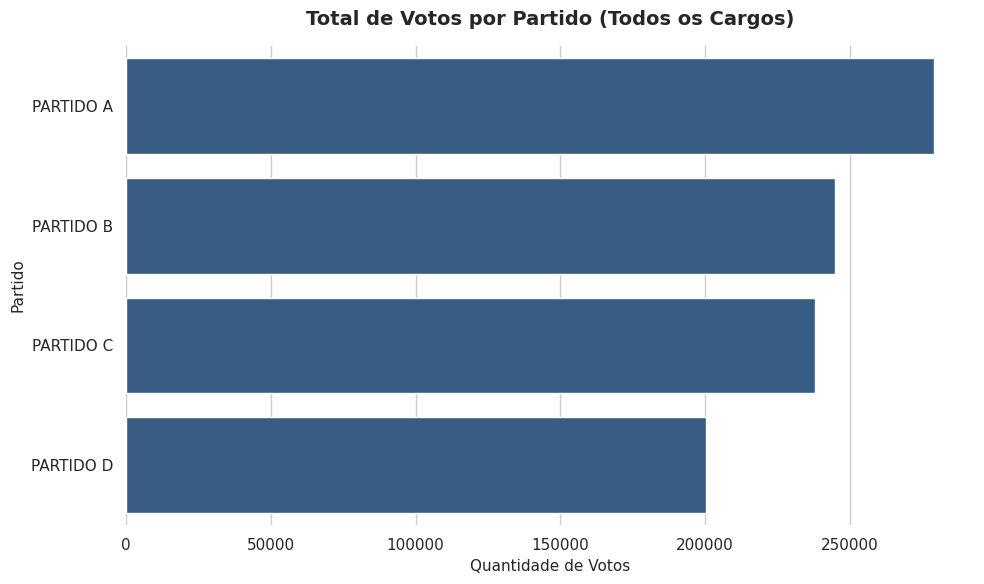

In [80]:

df_partidos = df_tse.groupby('SG_PARTIDO')['QT_VOTOS'].sum().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots()

sns.barplot(x='QT_VOTOS', y='SG_PARTIDO', data=df_partidos, color='#2b5c8f', ax=ax)


ax.set_title('Total de Votos por Partido (Todos os Cargos)', fontsize=14, pad=15, weight='bold')
ax.set_xlabel('Quantidade de Votos', fontsize=11)
ax.set_ylabel('Partido', fontsize=11)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


 Gráfico de Linhas: Muito útil para comparação através de uma linha do tempo


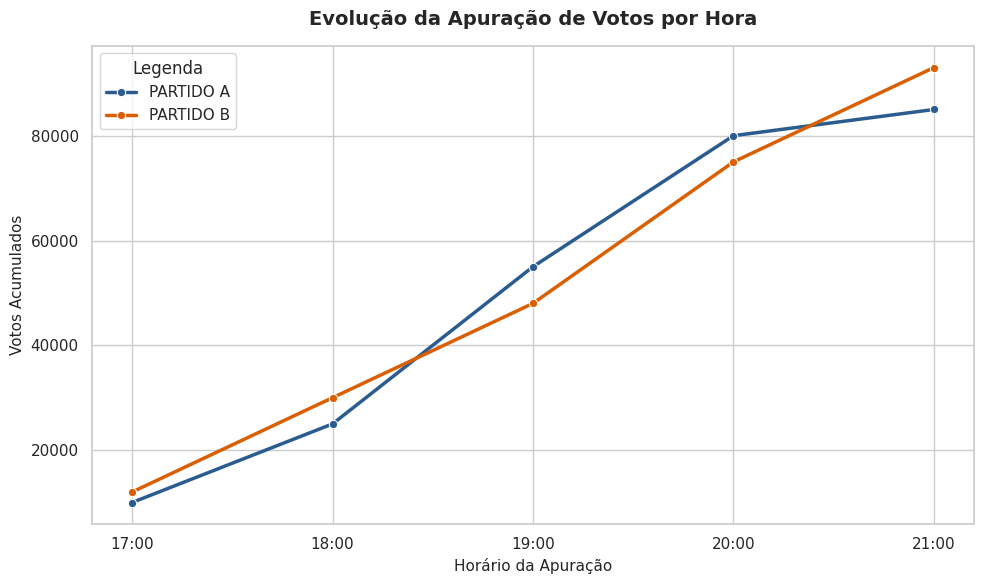

In [81]:

horas = ['17:00', '18:00', '19:00', '20:00', '21:00']
dados_tempo = {
    'Hora': horas * 2,
    'Partido': ['PARTIDO A'] * 5 + ['PARTIDO B'] * 5,
    'Votos_Acumulados': [10000, 25000, 55000, 80000, 85000, 12000, 30000, 48000, 75000, 93000]
}
df_linha = pd.DataFrame(dados_tempo)

fig, ax = plt.subplots()

sns.lineplot(x='Hora', y='Votos_Acumulados', hue='Partido', marker='o',
             palette=['#2b5c8f', '#d95f02'], data=df_linha, linewidth=2.5, ax=ax)

ax.set_title('Evolução da Apuração de Votos por Hora', fontsize=14, pad=15, weight='bold')
ax.set_xlabel('Horário da Apuração', fontsize=11)
ax.set_ylabel('Votos Acumulados', fontsize=11)
ax.legend(title='Legenda')

plt.tight_layout()
plt.show()


Gráfico de Barras Empilhadas:Muito útil para visualizar as subdivisões de uma categoria


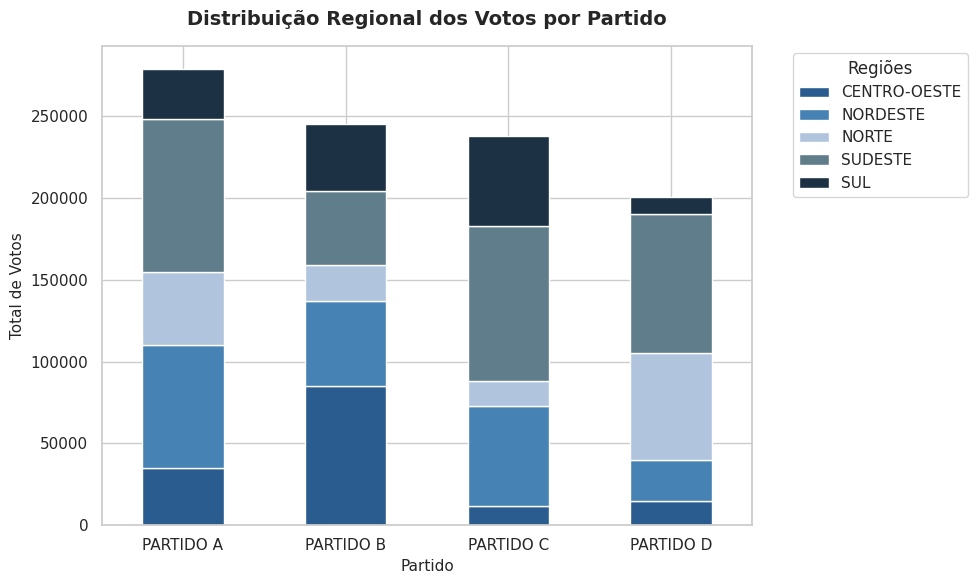

In [82]:

df_pivot = df_tse.pivot_table(index='SG_PARTIDO', columns='REGIAO', values='QT_VOTOS', aggfunc='sum')


ax = df_pivot.plot(kind='bar', stacked=True, color=['#2b5c8f', '#4682b4', '#b0c4de', '#607d8b', '#1c3144'])

ax.set_title('Distribuição Regional dos Votos por Partido', fontsize=14, pad=15, weight='bold')
ax.set_xlabel('Partido', fontsize=11)
ax.set_ylabel('Total de Votos', fontsize=11)
plt.xticks(rotation=0) # Mantém os nomes dos partidos na horizontal
ax.legend(title='Regiões', bbox_to_anchor=(1.05, 1), loc='upper left') # Legenda externa para não poluir o gráfico

plt.tight_layout()
plt.show()


Gráfico de Pizza:Muito útil para comparação de poucas categorias



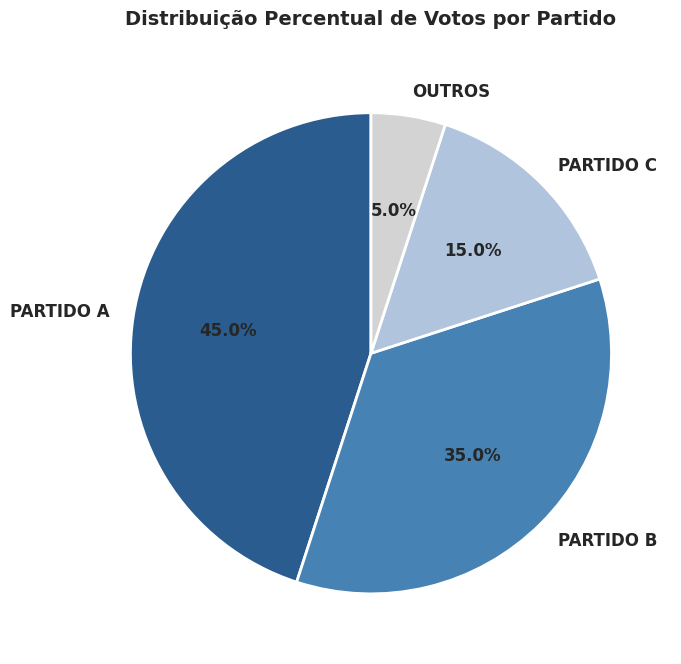

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

dados_pizza = {
    'PARTIDO': ['PARTIDO A', 'PARTIDO B', 'PARTIDO C', 'OUTROS'],
    'VOTOS_TOTAIS': [45000, 35000, 15000, 5000]
}
df_pizza = pd.DataFrame(dados_pizza)

cores_guia = ['#2b5c8f', '#4682b4', '#b0c4de', '#d3d3d3']

fig, ax = plt.subplots(figsize=(7, 7))


ax.pie(
    df_pizza['VOTOS_TOTAIS'],
    labels=df_pizza['PARTIDO'],
    autopct='%1.1f%%',          # Mostra o percentual com uma casa decimal
    startangle=90,              # Rotaciona o gráfico para começar no topo (12h)
    colors=cores_guia,
    textprops={'fontsize': 12, 'weight': 'bold'}, # Melhora a fonte dos textos
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} # Adiciona uma linha branca separando as fatias
)

ax.set_title('Distribuição Percentual de Votos por Partido', fontsize=14, pad=20, weight='bold')

plt.tight_layout()
plt.show()
